<a href="https://colab.research.google.com/github/Sujal-Sharma-Codes/Prodigy-GA-2/blob/main/stable_diffusion_image_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-02: Image Generation with Pre-trained Models
Generate images from text prompts using Stable Diffusion v1.5 (Hugging Face `diffusers`).

**Before running:** Runtime → Change runtime type → T4 GPU.

## 1. Install libraries

In [1]:
!pip -q install -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 16.0 MB/s eta 0:00:00


## 2. Load the pre-trained model
The first run downloads the model weights (a few GB), so it takes a few minutes.

In [2]:
import os
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

os.makedirs("outputs", exist_ok=True)
print("Model loaded")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded


## 3. Helper function

In [3]:
def make(prompt, seed=42, steps=30, guidance=7.5,
         negative="blurry, low quality, distorted, deformed, text, watermark"):
    gen = torch.Generator("cuda").manual_seed(seed)
    return pipe(
        prompt,
        negative_prompt=negative,
        num_inference_steps=steps,
        guidance_scale=guidance,
        generator=gen,
    ).images[0]

from PIL import Image

def grid(images, labels=None):
    w, h = images[0].size
    canvas = Image.new("RGB", (w * len(images), h), "white")
    for i, im in enumerate(images):
        canvas.paste(im, (i * w, 0))
    return canvas

## 4. Generate images from different prompts

  0%|          | 0/30 [00:00<?, ?it/s]

PROMPT: a photo of an astronaut riding a horse on mars, cinematic lighting, highly detailed


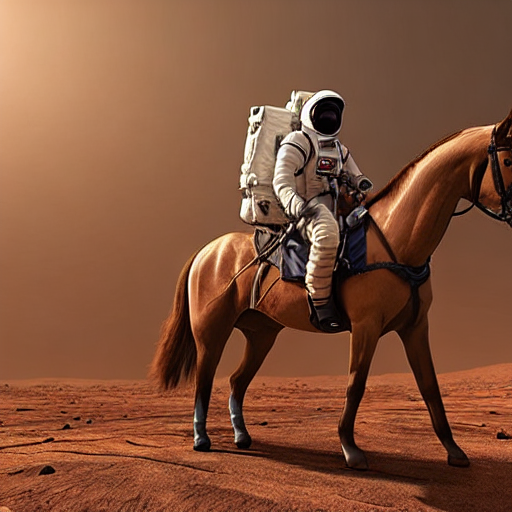

  0%|          | 0/30 [00:00<?, ?it/s]

PROMPT: a futuristic city at sunset with flying cars, digital art, vibrant colors


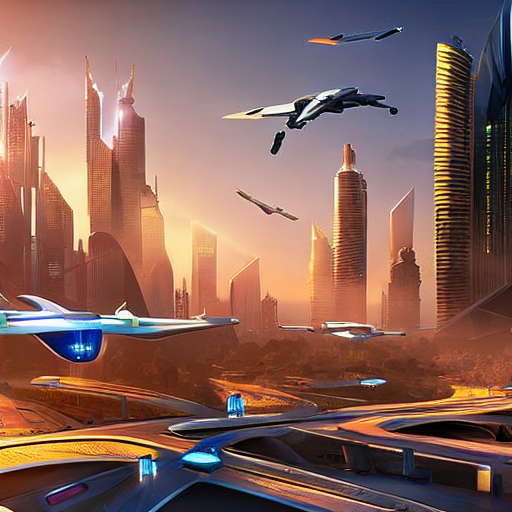

  0%|          | 0/30 [00:00<?, ?it/s]

PROMPT: a cute orange cat wearing sunglasses on a beach, realistic photo


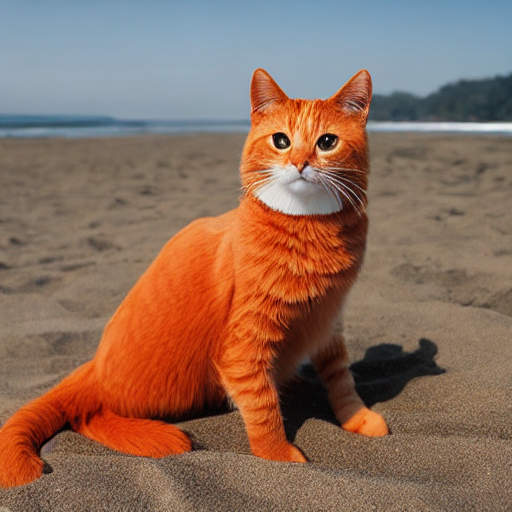

  0%|          | 0/30 [00:00<?, ?it/s]

PROMPT: a medieval castle on a mountain in the fog, fantasy painting


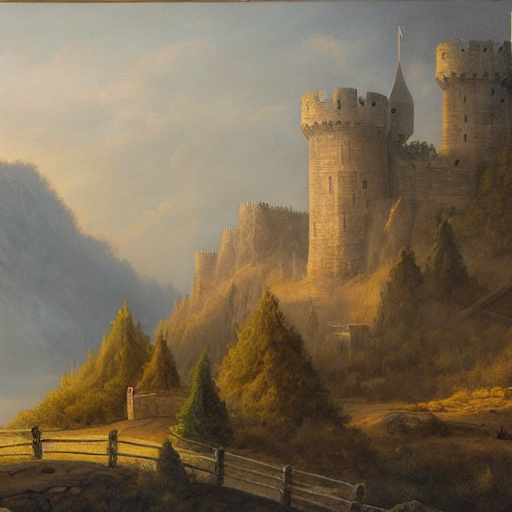

In [4]:
prompts = {
    "astronaut": "a photo of an astronaut riding a horse on mars, cinematic lighting, highly detailed",
    "city": "a futuristic city at sunset with flying cars, digital art, vibrant colors",
    "cat": "a cute orange cat wearing sunglasses on a beach, realistic photo",
    "castle": "a medieval castle on a mountain in the fog, fantasy painting",
}

results = {}
for name, p in prompts.items():
    img = make(p)
    img.save(f"outputs/{name}.png")
    results[name] = img
    print("PROMPT:", p)
    display(img)

## 5. Effect of prompt detail
Same seed, a simple prompt vs a detailed prompt.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

LEFT: a dog
RIGHT: a golden retriever puppy sitting in a field of flowers, golden hour lighting, shallow depth of field, professional photography, highly detailed


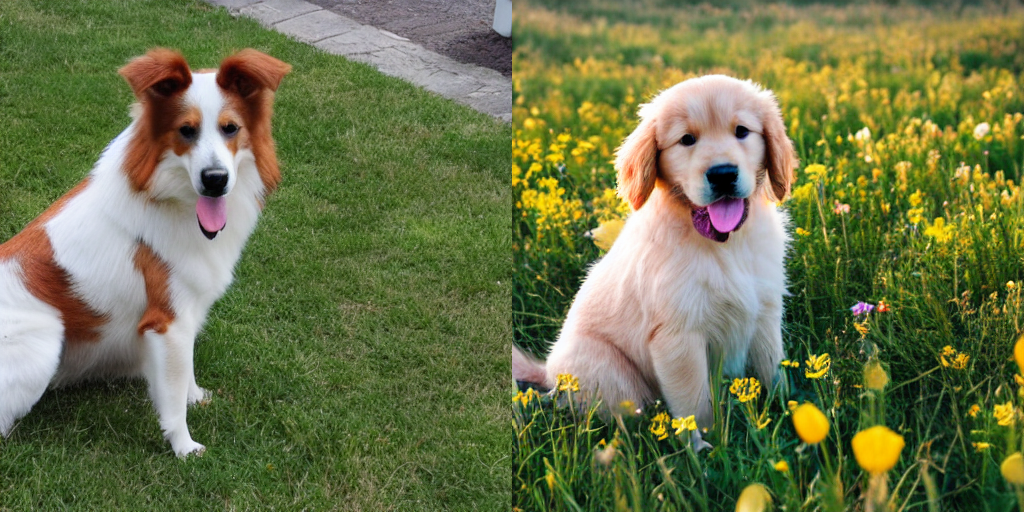

In [5]:
simple = "a dog"
detailed = "a golden retriever puppy sitting in a field of flowers, golden hour lighting, shallow depth of field, professional photography, highly detailed"

img_simple = make(simple, seed=7)
img_detailed = make(detailed, seed=7)
comparison = grid([img_simple, img_detailed])
comparison.save("outputs/prompt_detail_comparison.png")
print("LEFT:", simple)
print("RIGHT:", detailed)
display(comparison)

## 6. Effect of guidance scale
Same prompt and seed with guidance scale 3, 7.5 and 15. Low values follow the prompt loosely; high values follow it strictly but can look over-saturated.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Guidance scale: 3 (left), 7.5 (middle), 15 (right)


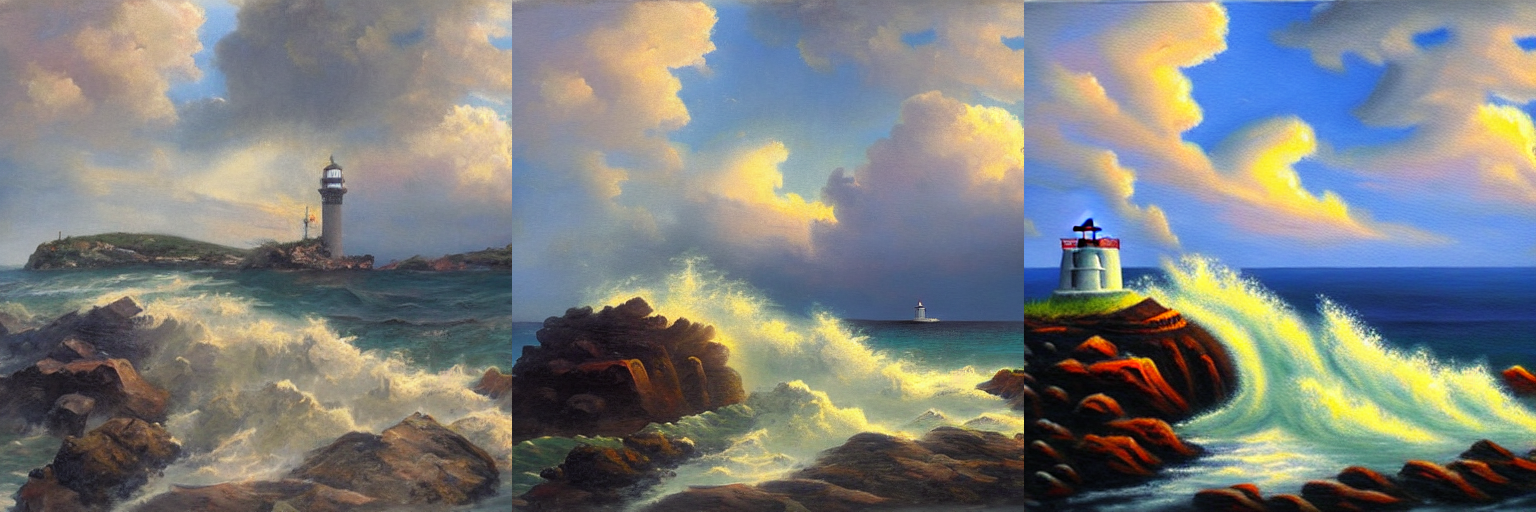

In [6]:
p = "a lighthouse on a rocky coast during a storm, dramatic sky, oil painting"
imgs = [make(p, seed=11, guidance=g) for g in (3, 7.5, 15)]
gs = grid(imgs)
gs.save("outputs/guidance_comparison.png")
print("Guidance scale: 3 (left), 7.5 (middle), 15 (right)")
display(gs)